In [14]:
## Batam Cloud-Free Composite 2025
# Using 2 scenes of Landdsat Satellite Imagery
# Landsat 9 Collection 2 Level 2
# Surface Reflectance (SR)
# use QA_PIXEL
# scene 1 : 2025/07/06
# scene 2 : 2025/12/05

import geopandas as gpd
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.mask import mask

## Read the boundary
kota_utm = gpd.read_file('../data/boundaries/KOTA BATAM/kota_utm.geojson')
case_kota = kota_utm.copy()

kecamatan_utm = gpd.read_file('../data/boundaries/KOTA BATAM/kecamatan_utm.geojson')
case_kecamatan = kecamatan_utm[
    kecamatan_utm['NAMOBJ'] == 'Sei Beduk'
].copy()

## Read Landsat Scene Directory
from pathlib import Path

lc_dir = Path (
    "/Volumes/HOLMES/SATELLITE/landsat"
)

scene1 = lc_dir / "20250706"

scene2 = lc_dir / "20251205"

## Open Scene function
def open_scene(scene_path):
    scene = {}

    for band in range (1,8):

        file = list(
            scene_path.glob(
                f"*SR_B{band}.TIF"
            )
        )[0]

        scene[f"B{band}"]=rio.open(file)

    qa_file = list(
        scene_path.glob(
            "*QA_PIXEL.TIF"
        )
    )[0]

    scene["QA"] = rio.open(qa_file)

    return scene

## Read 2 data (20250706 & 20251205)
july = open_scene(scene1)
dec = open_scene(scene2)

## QA_PICEL Cloud Mask
def create_cloud_mask(qa):
    cloud = (qa & (1 << 3)) !=0

    shadow = (qa & (1 << 4)) !=0

    mask_valid = ~(
        cloud | shadow
    )

    return mask_valid

## Clip Function
def clip_band(src, boundary):

    clipped, transform = mask(
        src,
        boundary.geometry,
        crop=True
    )

    return (
        clipped[0],
        transform
    )

## Process July Scene
july_data = {}

qa_july, transform = clip_band(
    july["QA"],
    case_kota
)

valid_july = create_cloud_mask(
    qa_july
)

## Loop All Bands
for band in range (1,8):

    arr, transform = clip_band(
        july[f"B{band}"],
        case_kota
    )

    arr = arr.astype(
        "float32"
    )

    arr[
        ~valid_july
    ] = np.nan

    july_data[band] = arr

## Process December Data
dec_data = {}

qa_dec, _ = clip_band(
    dec["QA"],
    case_kota
)

valid_dec = create_cloud_mask(
    qa_dec
)

## Loop All December Bands
for band in range (1,8):

    arr, _ = clip_band(
        dec[f"B{band}"],
        case_kota
    )

    arr = arr.astype(
        "float32"
    )

    arr[
        ~valid_dec
    ] = np.nan

    dec_data[band] = arr

## Mosaic Bands
mosaic = {}

# Loop
for band in range (1,8):

    stack = np.stack(
        [
            dec_data[band],
            july_data[band]
        ]
    )

    mosaic[band] = np.nanmedian(
        stack,
        axis = 0
    )

/var/folders/7f/xbg63s494n9cmnvn__vb08zc0000gn/T/ipykernel_98866/7449511.py:162: RuntimeWarning: All-NaN slice encountered
  mosaic[band] = np.nanmedian(


<function matplotlib.pyplot.show(close=None, block=None)>

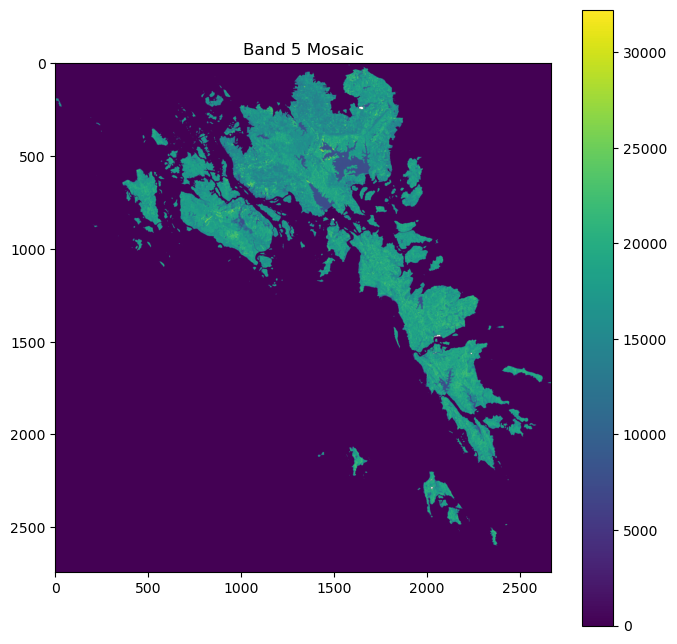

In [15]:
## Quick Check
plt.figure(
    figsize=(8,8)
)

plt.imshow(
    mosaic[5]
)

plt.title(
    "Band 5 Mosaic"
)

plt.colorbar()

plt.show

In [18]:
output_mosaic = Path(
    "/Volumes/HOLMES/SATELLITE/landsat/mosaic_raster"
)


## Export Meta Data
meta = july["B1"].meta.copy()

meta.update(
    {
        "height":
            mosaic[1].shape[0],

        "width":
            mosaic[1].shape[1],

        "transform":
            transform,

        "count":
            1,

        "dtype":
            "float32"
    }
)

## Export All Bands
for band in range(1,8):
    output_raster = (
        output_mosaic /
        f"batam_mosaic_2025_B{band}.tif"
    )

    with rio.open(
        output_raster,
        "w",
        **meta
    ) as dst:
        
        dst.write(
            mosaic[band].astype(
                "float32"
            ),
            1
        )

    print(
        f"Saved B{band}"
    )

Saved B1
Saved B2
Saved B3
Saved B4
Saved B5
Saved B6
Saved B7
